In [2]:
import torch
import torch.nn as nn
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
class FullyConnectedMLP(nn.Module): #Inheriths from the NN base class
    """
    This class defines a fully connected neural network in Pytorch
    """
    def __init__(self,input,output,hidden,layers):
        """TODO: Explain the architecture

        Args:
            input (_type_): _description_
            output (_type_): _description_
            hidden (_type_): _description_
            layers (_type_): _description_
        """
        super().__init__()
        activation=nn.Tanh ## A Tanh Activation function for Smoothness
        self.fcs = nn.Sequential(*[nn.Linear(input,hidden),activation()])
        self.fch = nn.Sequential(*[nn.Sequential(
            *[nn.Linear(hidden,hidden),activation()]) for _ in range(layers-1)
        ])
        self.fce= nn.Linear(hidden,output)
        
    def forward(self,x):
        x=self.fcs(x)
        x=self.fch(x)
        x=self.fce(x)
        return x

We want to train the MLP with the loss function

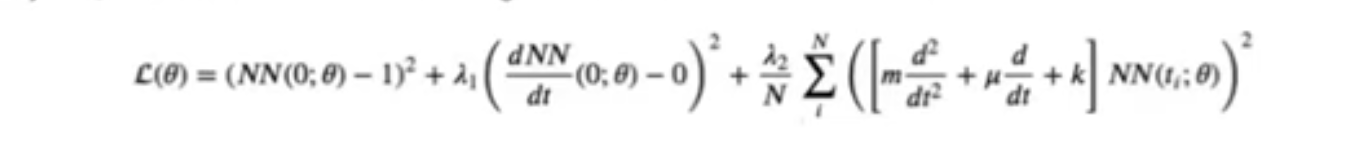

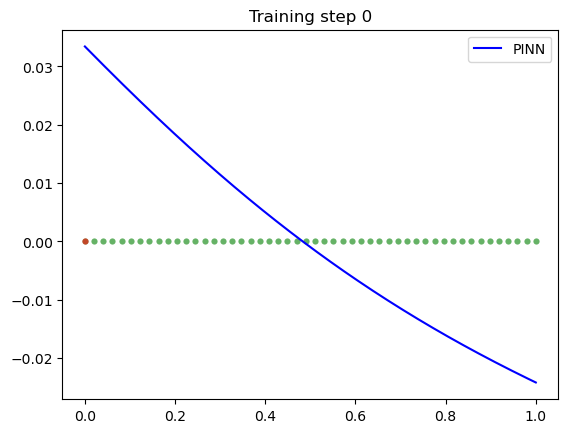

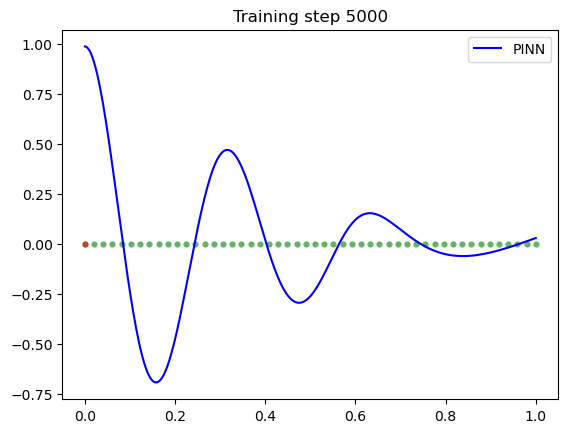

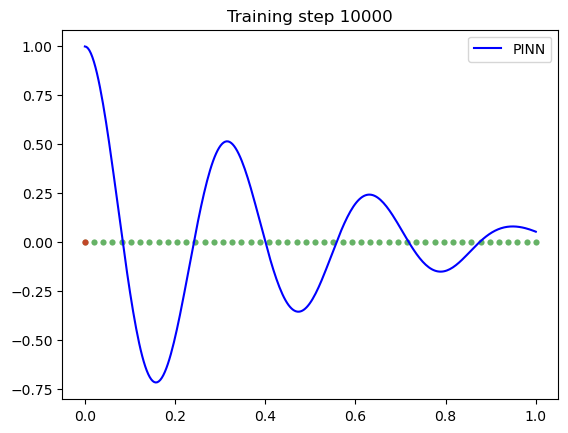

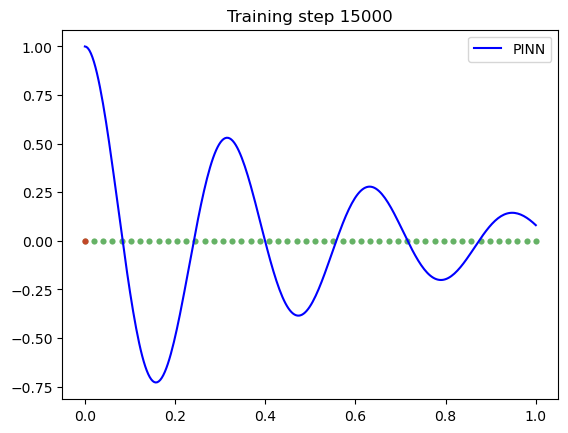

In [5]:
torch.manual_seed(42) # setting the random seed

pinn=FullyConnectedMLP(1,1,32,3) ## We decide on the network neurons and layers


## we need to define the boundary points, so the boundary loss can be computed
tBoundary=torch.tensor(0.,requires_grad=True).view(-1,1) 
# the requires grad is such that this is part of the graph where autodiff is 
# computed, while view just gives me the shape of the tensor, -1 infers it from
# the other dims


# next we need to specidy the range on which we want to train our pinn
# this is used to evaulate the physics loss
t_physics=torch.linspace(0,1,50,requires_grad=True).view(-1,1)

# The next step is to train the pinn

#parameters 

d,w0 =2,20
mu,k =2*d,w0**2
t_test = torch.linspace(0,1,300).view(-1,1)
optimiser=torch.optim.Adam(pinn.parameters(),lr=1e-3)
for i in range(15001):
    optimiser.zero_grad()
    #HyperParameters
    lam1,lam2=1e-1,1e-4
    
    # computing the boundary loss from the initial conditions
    u=pinn(tBoundary)
    boundary_loss_pos= torch.squeeze((u-1)**2)
    # squeeze turns it into a scalar value, this is just the difference between
    # the PINN and the initial condition x(0)=1
    v=torch.autograd.grad(u,tBoundary,torch.ones_like(u),create_graph=True)[0] 
    # the derivative of the network at t=0
    # the velocity
    boundary_loss_vel= torch.squeeze((v-0)**2)
    #v(0)=0
    
    
    #Now we need to compute the physics loss
    u=pinn(t_physics)
    v=torch.autograd.grad(u,t_physics,torch.ones_like(u),create_graph=True)[0] 
    a=torch.autograd.grad(v,t_physics,torch.ones_like(u),create_graph=True)[0] 
    physics_loss= torch.mean((a+mu*v+k*u-0)**2) # the residual of the equation
    loss=boundary_loss_pos+lam1*boundary_loss_vel+lam2*physics_loss
    loss.backward()
    optimiser.step()
    if i%5000==0:
        u=pinn(t_test).detach()
        plt.scatter(t_physics.detach()[:,0],
                    torch.zeros_like(t_physics).detach()[:,0],s=20,lw=0,color="g",alpha=0.6)
        plt.scatter(tBoundary.detach()[:,0],
                    torch.zeros_like(tBoundary).detach()[:,0],s=20,lw=0,color="r",alpha=0.6)
        plt.plot(t_test[:,0],u[:,0],color="b",label="PINN")
        plt.title(f"Training step {i}")
        plt.legend()
        plt.show()